In [2]:
import os, shutil

In [7]:
import zipfile

zip_path = "dogvscat_small.zip"  # Wpisz tu dokładną nazwę pliku z Kaggle
extract_dir = "data/"

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Rozpakowano!")

In [8]:
for root, dirs, files in os.walk("data"):
    depth = root.count(os.sep)
    if depth <= 2:  # Ograniczenie do 2 poziomów w głąb
        print(f"{root}/  ({len(files)} plików)")

data/  (1 plików)
data/__MACOSX/  (1 plików)
data/__MACOSX/dogvscat_small/  (4 plików)
data/dogvscat_small/  (1 plików)
data/dogvscat_small/test/  (1 plików)
data/dogvscat_small/train/  (0 plików)
data/dogvscat_small/validation/  (1 plików)


In [12]:
import os

base_path = "data/dogvscat_small"

for split in ["train", "validation", "test"]:
    split_path = os.path.join(base_path, split)
    if os.path.exists(split_path):
        for category in os.listdir(split_path):
            category_path = os.path.join(split_path, category)
            # Sprawdź, czy to folder i pomiń ukryte pliki (np. .DS_Store z Maca)
            if os.path.isdir(category_path) and not category.startswith("."):
                files = [f for f in os.listdir(category_path) if not f.startswith(".")]
                print(f"{split}/{category}: {len(files)} zdjęć")

train/dogs: 1000 zdjęć
train/cats: 1000 zdjęć
validation/dogs: 500 zdjęć
validation/cats: 500 zdjęć
test/dogs: 500 zdjęć
test/cats: 500 zdjęć


In [13]:
from keras import layers
from keras import models

In [51]:
from tensorflow.keras import layers, models, optimizers

model = models.Sequential([
    # 1. KONTRAKT WEJŚCIA: Wymiary pojedynczego zdjęcia (wysokość, szerokość, RGB)
    layers.Input(shape=(150, 150, 3)),

    # --------------------------------------------------------------------------
    # 2. AUGMENTACJA DANYCH (WKLEJASZ TUTAJ – PRZED KONWOLUCJĄ)
    # --------------------------------------------------------------------------
    layers.RandomFlip("horizontal"),     # Losowe odbicie lustrzane (lewo-prawo)
    layers.RandomRotation(0.1),          # Losowy obrót o max. 10% (ok. 36 stopni)
    layers.RandomZoom(0.1),              # Losowy zoom (przybliżenie/oddalenie) o 10%
    
    # --------------------------------------------------------------------------
    # 3. NORMALIZACJA PIKSELI
    # --------------------------------------------------------------------------
    layers.Rescaling(1./255),            # Przeliczenie zakresu [0, 255] -> [0.0, 1.0]

    # --------------------------------------------------------------------------
    # 4. BLOKI SPLOTOWE (EKSTRAKCJA CECH)
    # --------------------------------------------------------------------------
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # --------------------------------------------------------------------------
    # 5. KLASYFIKATOR Z REGULARYZACJĄ (DROPOUT)
    # --------------------------------------------------------------------------
    layers.Flatten(),                    # Rozwinięcie mapy cech 3D do wektora 1D
    layers.Dropout(0.5),                 # Losowo zeruje 50% neuronów (niszczy overfitting)
    layers.Dense(512, activation='relu'),# Warstwa gęsta decyzyjna
    layers.Dense(1, activation='sigmoid')# Wyjście binarne: prawdopodobieństwo (kot/pies)
])

# Kompilacja z mniejszym współczynnikiem uczenia dla stabilizacji
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)

In [52]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# filtr o rozmiarze 3x3 i 3 kanaly - r g b. params to 3 * 3 * 3(rgb)+ 1(bias) * 32(ilosc filtrow) = 896
# kolejne to 3 * 3 * 64 +1) * 64 = 18496

In [54]:
from tensorflow.keras import optimizers

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)

In [55]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/dogvscat_small/train",
    image_size=(150, 150),
    batch_size=20,
    label_mode='binary'  # Zwraca etykiety jako float32 o wymiarze (batch_size, 1)
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/dogvscat_small/validation",
    image_size=(150, 150),
    batch_size=20,
    label_mode='binary'
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [56]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

In [57]:
val_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

In [58]:
# train_ds.take(1) pobiera ze strumienia dokładnie jedną paczkę danych (bez wczytywania reszty do RAM-u)
# Każdy element datasetu to krotka: (tensor_obrazów, tensor_etykiet)
for images, labels in train_ds.take(1):
    
    # images.shape zwraca 4 wymiary: (batch_size, wysokość, szerokość, kanały_RGB)
    print("Kształt batcha obrazów:", images.shape)   # np. (32, 150, 150, 3)
    
    # labels.shape zwraca wymiary wektora odpowiedzi: (batch_size, 1)
    print("Kształt batcha etykiet:", labels.shape)   # np. (32, 1)
    
    # dtype pokazuje format liczb – sieć wymaga float32 do obliczania wag i gradientów
    print("Typ danych pikseli:", images.dtype)        # tf.float32

Kształt batcha obrazów: (20, 150, 150, 3)
Kształt batcha etykiet: (20, 1)
Typ danych pikseli: <dtype: 'float32'>


In [59]:
history = model.fit(
    train_ds,                  # Źródło danych treningowych: strumień podający gotowe paczki (batch=32)
    epochs=30,                 # Liczba epok: ile razy model przejrzy CAŁY zbiór treningowy od zera
    validation_data=val_ds     # Dane walidacyjne: sprawdzian po każdej epoce na zdjęciach, których sieć się NIE uczy
    # Brak steps_per_epoch! Keras sam wie, ile kroków wykonać, bo train_ds zna swój rozmiar.
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5175 - loss: 0.6945

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - accuracy: 0.5175 - loss: 0.6945 - val_accuracy: 0.5420 - val_loss: 0.6882
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5520 - loss: 0.6879

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - accuracy: 0.5520 - loss: 0.6879 - val_accuracy: 0.6110 - val_loss: 0.6736
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5825 - loss: 0.6729

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.7715 - loss: 0.4677 - val_accuracy: 0.7650 - val_loss: 0.4731
Epoch 29/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.7805 - loss: 0.4626

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 0.7805 - loss: 0.4626 - val_accuracy: 0.7650 - val_loss: 0.4682
Epoch 30/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.7795 - loss: 0.4670

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.7795 - loss: 0.4670 - val_accuracy: 0.7600 - val_loss: 0.5003


In [60]:
# Zapisujemy cały model (architekturę, optymalizator oraz nauczone wagi) w nowoczesnym formacie .keras
model.save("cats_and_dogs_small_1.keras")

acc = history.history['accuracy']          # Dokładność na zbiorze treningowym w każdej epoce
val_acc = history.history['val_accuracy']  # Dokładność na zbiorze walidacyjnym
loss = history.history['loss']              # Wartość błędu (straty) na zbiorze treningowym
val_loss = history.history['val_loss']      # Wartość błędu na zbiorze walidacyjnym

In [61]:
import matplotlib.pyplot as plt

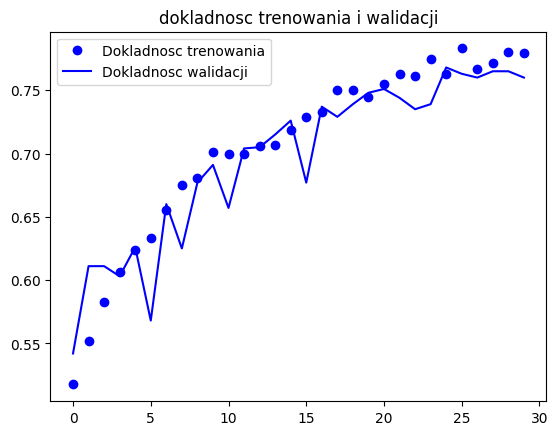

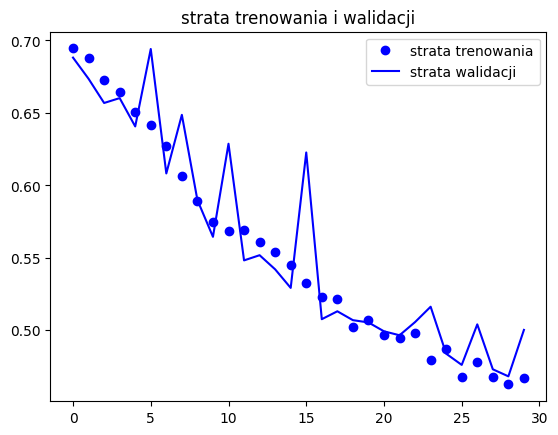

In [62]:
epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Dokladnosc trenowania')
plt.plot(epochs, val_acc, 'b', label = 'Dokladnosc walidacji')
plt.title('dokladnosc trenowania i walidacji')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='strata trenowania')
plt.plot(epochs, val_loss, 'b', label = 'strata walidacji')
plt.title('strata trenowania i walidacji')
plt.legend()
plt.show()

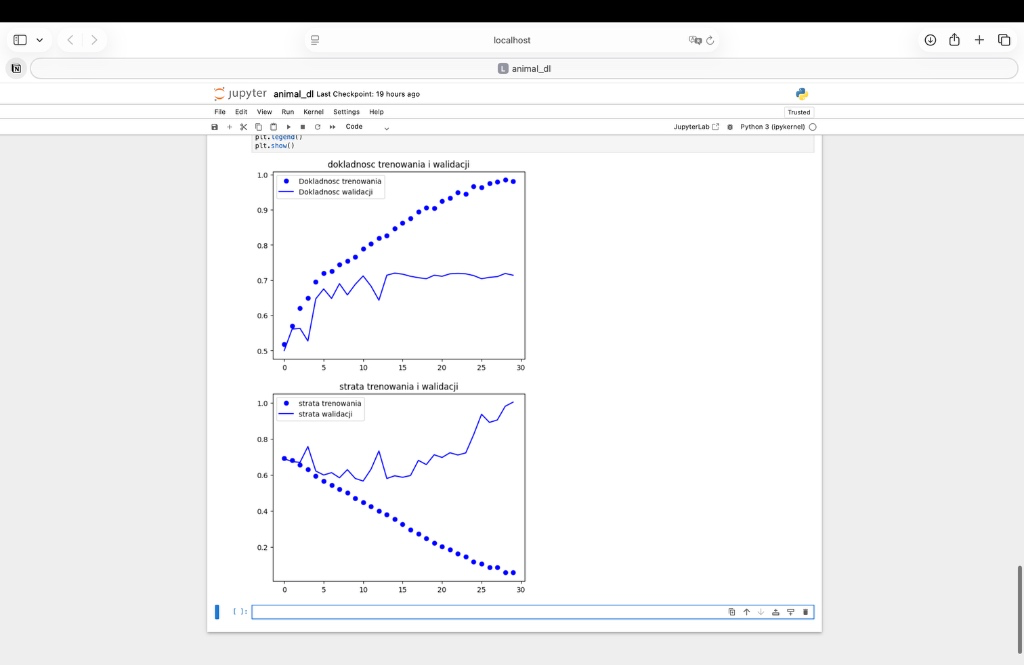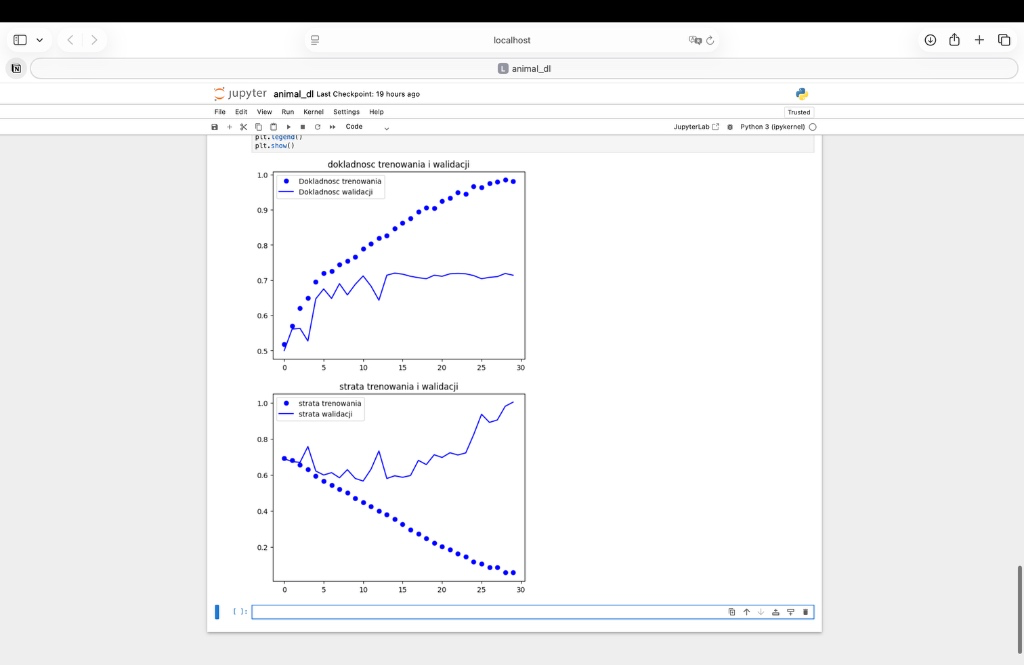
1. Przeuczenie (Overfitting) – Twój obecny przypadek:
Objaw: loss spada w dół (np. do 0.05), a val_loss po kilku epokach zaczyna rosnąć w górę (np. do 1.0).
Luka dokładności: Rozjazd między accuracy a val_accuracy większy niż 10–15 p.p. (u Ciebie: 98% vs 71%).
Diagnoza: Model wkuł zdjęcia z dysku na pamięć zamiast cech ogólnych.
2. Niedouczenie (Underfitting):
Objaw: Zarówno loss, jak i val_loss są wysokie i ledwo spadają, a accuracy kręci się blisko losowego trafiania (~50% dla dwóch klas).
Diagnoza: Model jest za prosty (za mało warstw), learning rate jest za mały lub dane wejściowe nie zostały znormalizowane (Rescaling).
3. Eksplozja gradientu / Za duży Learning Rate:
Objaw: W logach pojawia się loss: nan lub loss: inf, albo strata skacze chaotycznie z epoki na epokę (np. z 0.6 na 8.4, potem na 1.2).
Diagnoza: Krok optymalizatora przeskakuje minimum funkcji błędu i rozsadza wagi.
4. Wyciek danych (Data Leakage):
Objaw: val_accuracy wynosi 99–100% już w 1. lub 2. epoce.
Diagnoza: To nie geniusz modelu — te same zdjęcia przypadkowo znalazły się w folderze treningowym i walidacyjnym

# w zdjeciach wyzej mamy zastosowania augmentacje a nad tekstem jej nie bylo

In [50]:
# mamy okolo 3.5 mln parametrow i 2k zdj jest za malo zdj

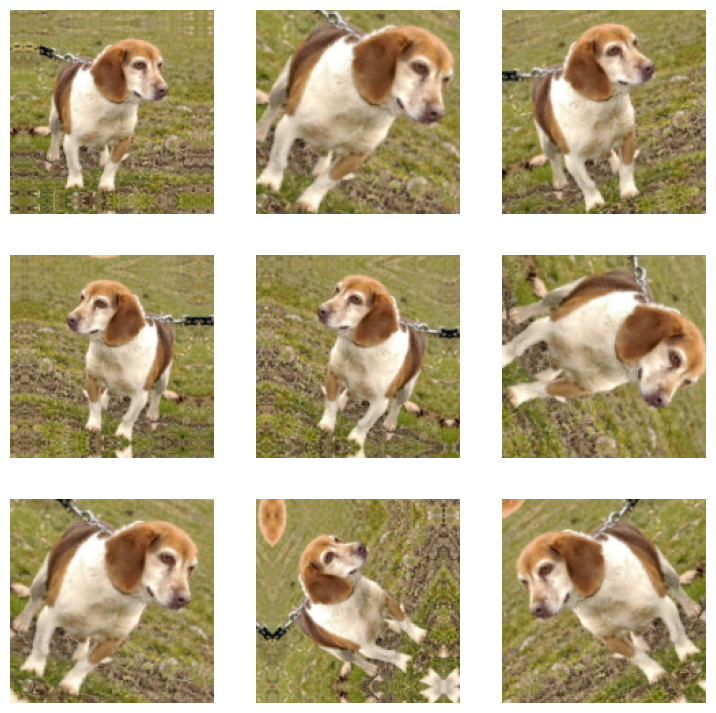

In [63]:
import tensorflow as tf

# 1. Definicja warstw przekształceń (dokładnie takich, jak w modelu)
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),                      # Odbicie w poziomie
    layers.RandomRotation(0.2),                           # Losowy obrót o max 20%
    layers.RandomZoom(0.2),                               # Losowy zoom o max 20%
])

# 2. Pobranie dokładnie jednego zdjęcia z gotowego datasetu train_ds
for images, _ in train_ds.take(1):
    sample_image = images[0]                              # Pierwszy obraz z pobranego batcha (150, 150, 3)
    break

# 3. Rysowanie siatki 3x3 (9 różnych wariacji tego samego zdjęcia)
plt.figure(figsize=(9, 9))
for i in range(9):
    # tf.expand_dims dodaje wymiar batcha: (150, 150, 3) -> (1, 150, 150, 3)
    # training=True zmusza warstwę do aktywacji losowości
    augmented_image = data_augmentation(tf.expand_dims(sample_image, 0), training=True)
    
    plt.subplot(3, 3, i + 1)
    # augmented_image[0] to pojedynczy tensor. astype("uint8") konwertuje liczby do zakresu pikseli 0-255
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.axis("off")

plt.show()

Utrudnienie zadania treningowego:
Wcześniej sieć miała banalne zadanie — te same 2000 klatek w kółko, więc błyskawicznie wbiła 98% (sztuczne dopasowanie). Po augmentacji każde zdjęcie w każdej epoce wygląda inaczej, więc błąd treningowy nie spada już tak gwałtownie do zera.

Likwidacja przepaści (Overfitting → Good Fit):
Zamiast rozjazdu (98% trening vs 71% walidacja), obie krzywe spotykają się w okolicach 82–85%. To stan optymalnego dopasowania — model ma zbliżoną skuteczność na danych, które widział, i na tych, których nigdy nie dotykał.

Wygładzenie i stabilizacja błędu walidacji (val_loss):
Zamiast wystrzelić w górę do 1.0 (jak na poprzednim wykresie), val_loss zaczyna stabilnie spadać razem z błędem treningowym, bo sieć nie podejmuje już ryzykownych decyzji opartych na przypadkowym tle.

Redukcja wariancji wag:
Matematycznie augmentacja działa jak regularyzator (podobnie jak L2 czy Dropout). Wymusza spłaszczenie przestrzeni wag — sieć nie reaguje histerycznie na przesunięcie kilku pikseli w bok, bo nauczyła się, że kot obrócony o 10 stopni to wciąż kot.

In [67]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ==============================================================================
# 1. POTOK DANYCH (ZAMIAST STAREGO ImageDataGenerator)
# ==============================================================================
#AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32
IMAGE_SIZE = (150, 150)

train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/dogvscat_small/train",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/dogvscat_small/validation",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Kesowanie w RAM i asynchroniczne buforowanie kolejnych batchy na GPU
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ==============================================================================
# 2. ARCHITEKTURA (AUGMENTACJA NA GPU + BLOKI CONV + DROPOUT)
# ==============================================================================
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Augmentacja danych w locie (wykonywana tylko podczas uczenia)
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # Normalizacja pikseli [0, 255] -> [0.0, 1.0]
    layers.Rescaling(1.0 / 255),

    # Ekstrakcja cech (piramida filtrów splotowych)
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Klasyfikator
    layers.Flatten(),
    layers.Dropout(0.5),                    # Niszczy wzajemną zależność neuronów
    layers.Dense(512, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# ==============================================================================
# 3. KOMPILACJA I CALLBACKI (STRAŻNICY MODELU)
# ==============================================================================
model.compile(
    loss="binary_crossentropy",
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=["accuracy"]
)

callbacks = [
    # Przerywa proces, gdy val_loss przestaje spadać przez 8 kolejnych epok
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    # Automatyczny zapis najlepszego stanu do natywnego formatu .keras (zamiast .h5)
    ModelCheckpoint(
        filepath="cats_and_dogs_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

# ==============================================================================
# 4. TRENING
# ==============================================================================
history = model.fit(
    train_ds,
    epochs=100,                              # Maksymalny limit (EarlyStopping zatrzyma wcześniej)
    validation_data=val_ds,
    callbacks=callbacks
)

# ==============================================================================
# 5. WIZUALIZACJA KRZYWYCH UCZENIA (DOKŁADNIE JAK U CHOLLETA)
# ==============================================================================
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Wykres dokładności
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, "bo", label="Dokladnosc trenowania")
plt.plot(epochs_range, val_acc, "b-", label="Dokladnosc walidacji")
plt.title("Dokladnosc trenowania i walidacji")
plt.xlabel("Epoki")
plt.ylabel("Accuracy")
plt.legend()

# Wykres straty
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, "bo", label="Strata trenowania")
plt.plot(epochs_range, val_loss, "b-", label="Strata walidacji")
plt.title("Strata trenowania i walidacji")
plt.xlabel("Epoki")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.5050 - loss: 0.6924

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9



Epoch 1: val_loss improved from None to 0.68866, saving model to cats_and_dogs_best.keras

Epoch 1: finished saving model to cats_and_dogs_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 179ms/step - accuracy: 0.5050 - loss: 0.6924 - val_accuracy: 0.6100 - val_loss: 0.6887
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.5525 - loss: 0.6883
Epoch 2: val_loss improved from 0.68866 to 0.67780, saving model to cats_and_dogs_best.keras

Epoch 2: finished saving model to cats_and_dogs_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.5525 - loss: 0.6883 - val_accuracy: 0.5890 - val_loss: 0.6778
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.5730 - loss: 0.6797
Epoch 3: val_loss improved from 0.67780 to 0.66480, saving model to cats_and_dogs_best.keras

Epoch 3: finished saving model to cats_and_dogs_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.5730 - loss: 0.6797 - val_accuracy: 0.5920 - val_loss: 0.6648
Epoch 4/100
63/

KeyboardInterrupt: 